# METEOR Description Paper: Seasonal and Noise Model Visualization

This notebook illustrates the capabilities of METEOR for generating ensemble members that combine seasonal patterns with realistic noise structures. We start with a global mean temperature plot comparing a 10-member METEOR ensemble for CESM2 RCP4.5 with the original experiment data.

## 1. Import Required Libraries

In [21]:
# Standard library imports
import warnings
warnings.filterwarnings('ignore')

# Third-party imports
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# METEOR import - import from the correct module
from meteor.meteor import Meteor as METEOR
import time
import meteor.prpatt as prpatt

from meteor import MeteorPatternScaling
import sys
from io import StringIO
import os
from ciceroscm import concentrations_emissions_handler, input_handler


## 2. Load Model Data from Cache

In [2]:
# Initialize CMIP6 data getter with cache enabled
from meteor import Cmip6MeteorDataGetter

# Set up the data getter for the experiments we need
# We'll use ssp245 (RCP4.5) along with piControl for the noise model
data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "ssp245", "historical", "abrupt-4xCO2"],
    flds=["tas"],  # Surface air temperature
    dbe=['CMIP', 'ScenarioMIP', 'CMIP', 'CMIP'   ],  # Project names for each experiment
    enable_cache=True  # Use cached data
)

print("Data getter initialized successfully!")
print(f"Available models: {data_getter.get_models_avail()}")

Data getter initialized successfully!
Available models: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'FGOALS-g3', 'FIO-ESM-2-0', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 'GISS-E2-1-H', 'HadGEM3-GC31-LL', 'IITM-ESM', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'KACE-1-0-G', 'KIOST-ESM', 'MCM-UA-1-0', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']


## 4. Calculate Global Mean Temperature

In [3]:
def calculate_global_mean(data):
    """Calculate area-weighted global mean temperature."""
    weights = np.cos(np.deg2rad(data.lat))
    weights.name = "weights"
    data_weighted = data.weighted(weights)
    return data_weighted.mean(dim=["lat", "lon"])


## 3. Set Up Regional Analysis Tools

In [4]:
# Install and import regionmask for AR6 regional analysis
try:
    import regionmask
    print("✅ regionmask already installed")
except ImportError:
    print("📦 Installing regionmask...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "regionmask", "-q"])
    import regionmask
    print("✅ regionmask installed successfully")

# Load AR6 regions
ar6_regions = regionmask.defined_regions.ar6.all
print(f"✅ AR6 regions loaded: {len(ar6_regions)} regions available")


✅ regionmask already installed
✅ AR6 regions loaded: 58 regions available


In [6]:
def calculate_regional_mean(data, region_code):
    """
    Calculate area-weighted regional mean for a specific AR6 region.
    
    Parameters
    ----------
    data : xr.DataArray
        Data with dimensions including 'lat' and 'lon'
    region_code : str
        AR6 region abbreviation (e.g., 'WNA', 'NEU', 'EAS', etc.)
    
    Returns
    -------
    xr.DataArray
        Regional mean time series
    """
    # Create mask for the specified region
    mask = ar6_regions.mask(data)
    
    # Find the region number for the given code
    region_number = None
    for region in ar6_regions:
        if region.abbrev == region_code:
            region_number = region.number
            region_name = region.name
            break
    
    if region_number is None:
        raise ValueError(f"Region code '{region_code}' not found in AR6 regions")
    
    # Apply mask to data
    regional_data = data.where(mask == region_number)
    
    # Calculate area-weighted mean
    weights = np.cos(np.deg2rad(regional_data.lat))
    weights.name = "weights"
    regional_weighted = regional_data.weighted(weights)
    regional_mean = regional_weighted.mean(dim=["lat", "lon"])
    
    # Add attributes
    regional_mean.attrs['region_code'] = region_code
    regional_mean.attrs['region_name'] = region_name
    
    return regional_mean


def list_ar6_regions():
    """List all available AR6 regions with their codes and names."""
    print("AR6 IPCC Reference Regions:")
    print("=" * 60)
    for region in ar6_regions:
        print(f"  {region.abbrev:6s} : {region.name}")
    print("=" * 60)
    print(f"Total: {len(ar6_regions)} regions")



print("\navailable regions:")
list_ar6_regions()


available regions:
AR6 IPCC Reference Regions:
  GIC    : Greenland/Iceland
  NWN    : N.W.North-America
  NEN    : N.E.North-America
  WNA    : W.North-America
  CNA    : C.North-America
  ENA    : E.North-America
  NCA    : N.Central-America
  SCA    : S.Central-America
  CAR    : Caribbean
  NWS    : N.W.South-America
  NSA    : N.South-America
  NES    : N.E.South-America
  SAM    : South-American-Monsoon
  SWS    : S.W.South-America
  SES    : S.E.South-America
  SSA    : S.South-America
  NEU    : N.Europe
  WCE    : West&Central-Europe
  EEU    : E.Europe
  MED    : Mediterranean
  SAH    : Sahara
  WAF    : Western-Africa
  CAF    : Central-Africa
  NEAF   : N.Eastern-Africa
  SEAF   : S.Eastern-Africa
  WSAF   : W.Southern-Africa
  ESAF   : E.Southern-Africa
  MDG    : Madagascar
  RAR    : Russian-Arctic
  WSB    : W.Siberia
  ESB    : E.Siberia
  RFE    : Russian-Far-East
  WCA    : W.C.Asia
  ECA    : E.C.Asia
  TIB    : Tibetan-Plateau
  EAS    : E.Asia
  ARP    : Arabian

## 5. Set Up Pattern Scaling Models

In [39]:
model_name = "CESM2"
scenario_train = "ssp245"

# Check if cached model exists
cache_dir = os.path.join("..", ".cache", "trained_pattern_scaling_models")
cache_file = os.path.join(cache_dir, f"cmip6-{model_name}-aer_pattern_scaling.pkl")

if os.path.exists(cache_file):
    print(f"📦 Cached model found: {cache_file}")
    print("   Skipping training data preparation and scenario configuration")
    # Set placeholders - won't be used since model will load from cache
    training_data = None
    ssp_config = None
else:
    print(f"🔧 No cached model found, preparing training data...")
    
    # Prepare training data dictionary
    training_data = {
        "base": data_getter.make_meteor_training_data("base", model_name),
        "co2x4": data_getter.make_meteor_training_data("co2x4", model_name),
        scenario_train: data_getter.make_meteor_training_data_composite(["historical", scenario_train], model_name)
    }
    for key, data in training_data.items():
        print(f"  {key}: {data['tas'].shape}")
        
    # Use ssp245 as the aerosol anomaly experiment (sulxanom)
    training_data["sulxanom"] = training_data[scenario_train]

    # Load scenario configuration
    scen_conc = input_handler.read_inputfile(os.path.join("..",
                            "src","meteor",
                            "default_scm_data",
                            f"{scenario_train}_conc_RCMIP.txt",
                        ))
    ih_temp = input_handler.InputHandler({})
    scen_em = ih_temp.read_emissions(os.path.join("..",
                            "src","meteor",
                            "default_scm_data",
                            f"{scenario_train}_em_RCMIP.txt",
                        ))

    ssp_config = {
        "emstart": 1850,
        "nystart": 1750,
        "nyend": 2100,
        "conc_run": False,
        "concentrations_data": scen_conc,
        "emissions_data": scen_em
    }


📦 Cached model found: ../.cache/trained_pattern_scaling_models/cmip6-CESM2-aer_pattern_scaling.pkl
   Skipping training data preparation and scenario configuration


In [41]:


# Create aerosol-inclusive pattern scaling model
pattern_model = MeteorPatternScaling(
    f"cmip6-{model_name}-aer",
    {"tas": 3} if training_data is None else {"tas": 3},  # 3 patterns for temperature
    None if training_data is None else lambda key: training_data[key],
    ssp_input=ssp_config,
    from_file=False,
    exp_list=None if training_data is None else ["base", "co2x4", "sulxanom"],
    anom_timescales=None if training_data is None else {"tas": 3},
    cache_dir=cache_dir
)


print(f"✅ Pattern scaling model created: {pattern_model.name}")

📦 Loading cached pattern scaling model from ../.cache/trained_pattern_scaling_models/cmip6-CESM2-aer_pattern_scaling.pkl
✅ Pattern scaling model loaded from ../.cache/trained_pattern_scaling_models/cmip6-CESM2-aer_pattern_scaling.pkl
✅ Pattern scaling model created: cmip6-CESM2-aer
✅ Pattern scaling model loaded from ../.cache/trained_pattern_scaling_models/cmip6-CESM2-aer_pattern_scaling.pkl
✅ Pattern scaling model created: cmip6-CESM2-aer


In [43]:
# Load original CMIP6 annual data for comparison with pattern scaling model
print("📥 Loading original CMIP6 annual data...")

# Get annual data (not monthly)
ssp245_annual = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], 
    model_name, 
    monthly=False
)["tas"]

pictrl_annual = data_getter.make_meteor_training_data(
    "piControl", 
    model_name, 
    monthly=False
)["tas"]

# Calculate global means
original_pictrl_annual_mean = calculate_global_mean(pictrl_annual)
original_ssp245_annual_mean = calculate_global_mean(ssp245_annual) - np.mean(original_pictrl_annual_mean)

print(f"✅ Original CMIP6 annual data loaded")
print(f"   SSP245 annual shape: {ssp245_annual.shape}")
print(f"   piControl annual shape: {pictrl_annual.shape}")

📥 Loading original CMIP6 annual data...
   Limiting piControl data to first 150 years (was 1200 years)
   Limiting piControl data to first 150 years (was 1200 years)
✅ Original CMIP6 annual data loaded
   SSP245 annual shape: (1, 251, 192, 288)
   piControl annual shape: (1, 150, 192, 288)
✅ Original CMIP6 annual data loaded
   SSP245 annual shape: (1, 251, 192, 288)
   piControl annual shape: (1, 150, 192, 288)


In [45]:
# Load forcing data for SSP245
import os
from ciceroscm import input_handler

# Data directory (adjust path as needed)
cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

# Load concentration and emission data
conc_file = os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt")
em_file = os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt")

ih = input_handler.InputHandler({})
conc_data = input_handler.read_inputfile(conc_file)
em_data = ih.read_emissions(em_file)

print(f"✅ Forcing data loaded for SSP245")
print(f"   Concentration data: {len(conc_data)} rows")
print(f"   Emission data: {len(em_data)} rows")

# Generate climate prediction using the aerosol-inclusive model
print("\n🌍 Generating climate prediction with aerosol effects...")
climate_prediction = pattern_model.predict_from_combined_experiment(
    em_data, 
    conc_data, 
    ["tas"]
)

temperature_prediction = climate_prediction["tas"]
print(f"✅ Climate prediction generated")
print(f"   Temperature shape: {temperature_prediction.shape}")


✅ Forcing data loaded for SSP245
   Concentration data: 801 rows
   Emission data: 751 rows

🌍 Generating climate prediction with aerosol effects...
11
12
113
114
115
22
141
123
142
✅ Climate prediction generated
   Temperature shape: (351, 192, 288)
✅ Climate prediction generated
   Temperature shape: (351, 192, 288)


## 6. Load Climate Forcing Data and Generate Annual Predictions


📊 Comparing METEOR pattern scaling with original CMIP6 data...


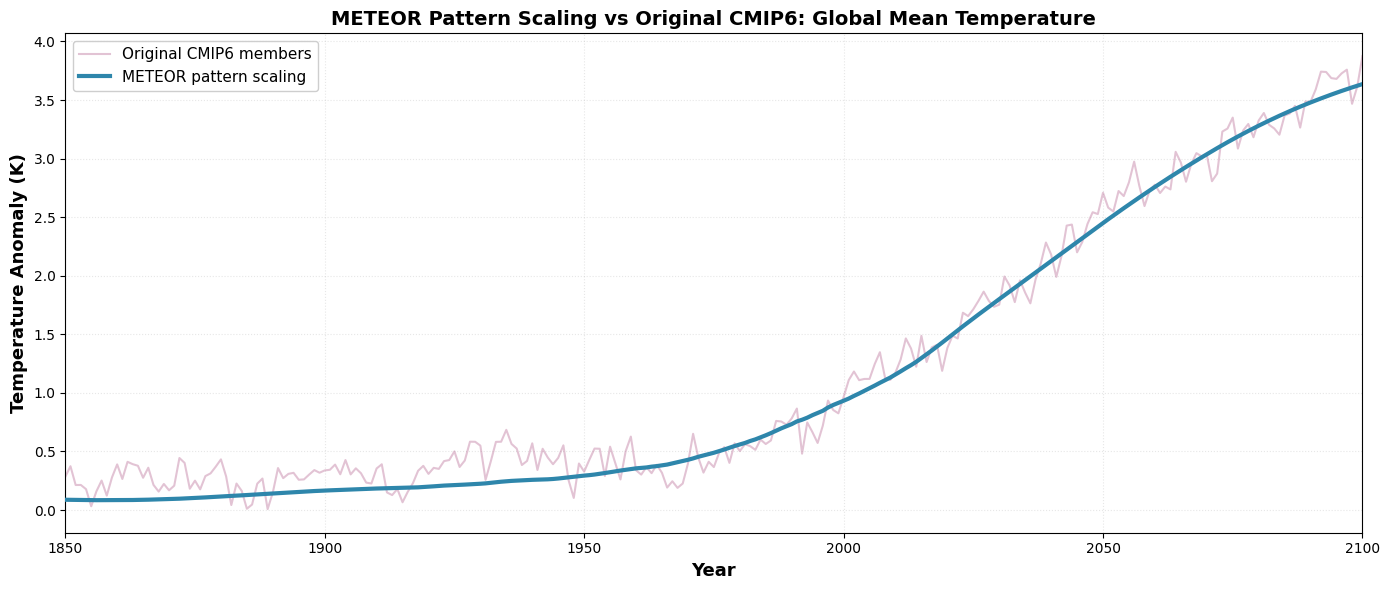


✅ Comparison plot created
   METEOR prediction: 351 years
   Original CMIP6: 251 years
   CMIP6 ensemble members: 1

💡 The METEOR pattern scaling captures the forced response
   without the internal variability present in individual CMIP6 members.


In [46]:
# Compare METEOR pattern scaling prediction with original CMIP6 annual data
print("\n📊 Comparing METEOR pattern scaling with original CMIP6 data...")

# Get METEOR prediction (annual, already calculated)
meteor_prediction_global = prpatt.global_mean(temperature_prediction).values

# Create time axes
years_original = np.arange(1850, 1850 + len(original_ssp245_annual_mean.values[0]))
years_meteor = np.arange(0, len(meteor_prediction_global))+1750  # Starts at year 0

# Plot comparison
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Plot original CMIP6 ensemble members
for i in range(ssp245_annual.shape[0]):
    ax.plot(years_original, original_ssp245_annual_mean.values[i], 
            color='#A23B72', alpha=0.3, linewidth=1.5, 
            label='Original CMIP6 members' if i == 0 else '')

# Plot METEOR prediction
ax.plot(years_meteor, meteor_prediction_global, 
        color='#2E86AB', linewidth=3, label='METEOR pattern scaling', 
        linestyle='-', zorder=10)

# Formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_title('METEOR Pattern Scaling vs Original CMIP6: Global Mean Temperature', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.set_xlim(1850, 2100)

plt.tight_layout()
plt.show()

print(f"\n✅ Comparison plot created")
print(f"   METEOR prediction: {len(meteor_prediction_global)} years")
print(f"   Original CMIP6: {len(original_ssp245_annual_mean.values[0])} years")
print(f"   CMIP6 ensemble members: {ssp245_annual.shape[0]}")
print("\n💡 The METEOR pattern scaling captures the forced response")
print("   without the internal variability present in individual CMIP6 members.")

## 7. Train Noise Model and Generate IC Ensemble

In [50]:
# Train noise model from CMIP6 data
from meteor.noise_generator import train_noise_model_from_cmip6, MeteorNoiseGenerator
from meteor import prpatt

# Set up noise cache directory
noise_cache_dir = os.path.join(os.getcwd(), "noise_cache")
noise_cache_file = os.path.join(noise_cache_dir, f"{model_name}_tas_noise_model.pkl")

# Check if cached noise model exists
if os.path.exists(noise_cache_file):
    print(f"📦 Cached noise model found: {noise_cache_file}")
    print("   Loading from cache...")
    
    # Load the cached model
    tas_noise_model = MeteorNoiseGenerator(n_modes=40, lag_order=2)
    tas_noise_model.load_model(noise_cache_file)
    
    # Still need monthly_prediction and monthly_warming for ensemble generation
    print("   Preparing monthly prediction data...")
    monthly_prediction = pattern_model.to_monthly(temperature_prediction, start_year=0)
    monthly_warming = prpatt.global_mean(monthly_prediction).values
    
    print(f"✅ Noise model loaded from cache")
    
else:
    print(f"🔧 No cached noise model found, training new model...")
    
    # Convert annual predictions to monthly
    monthly_prediction = pattern_model.to_monthly(temperature_prediction, start_year=0)
    monthly_warming = prpatt.global_mean(monthly_prediction).values
    
    # Skip first 100 years (spin-up)
    monthly_warming_trimmed = monthly_warming[1200:]  # 100 years * 12 months
    
    # Train the noise model
    tas_noise_model = train_noise_model_from_cmip6(
        data_getter,
        experiments=["historical", "ssp245"],
        model_name=model_name,
        variable_name="tas",
        n_modes=40,  # Number of PCA modes
        lag_order=2,  # Temporal lag
        custom_global_temp=monthly_warming_trimmed,
        use_picontrol_baseline=True,
        cache_dir=noise_cache_dir
    )
    
    print(f"✅ Noise model trained successfully")
    print(f"   Training length: {len(monthly_warming_trimmed)//12} years")

📦 Cached noise model found: /Users/bensan/Documents/Github/METEOR/notebooks/noise_cache/CESM2_tas_noise_model.pkl
   Loading from cache...
Model loaded from /Users/bensan/Documents/Github/METEOR/notebooks/noise_cache/CESM2_tas_noise_model.pkl
   Preparing monthly prediction data...
✅ Noise model loaded from cache
✅ Noise model loaded from cache


### Comprehensive Demonstration: Global, Regional, and Point-Scale

Create a 3-panel figure showing 100-member ensembles at different spatial scales.

In [51]:
# Generate 100-member ensemble for demonstration

n_demo = 100
start = time.time()

# Generate stochastic PCs once for all locations
demo_pcs = tas_noise_model.generate_stochastic_pcs(
    monthly_warming,
    n_realizations=n_demo,
    random_seed=123
)
print(f"✅ Generated {n_demo} stochastic PCs")


✅ Generated 100 stochastic PCs


In [52]:
# Load original CESM2 SSP245 data for comparison
print("📥 Loading original CESM2 SSP245 monthly data from cache...")

ssp245_data = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], 
    model_name, 
    monthly=True
)["tas"]

pictrl_data = data_getter.make_meteor_training_data(
    "piControl", 
    model_name, 
    monthly=True
)["tas"]

# Calculate global mean for the original SSP245 data
original_pictrl_global_mean = calculate_global_mean(pictrl_data)
original_global_mean = calculate_global_mean(ssp245_data) - np.mean(original_pictrl_global_mean)

# Calculate regional means for NEU (Northern Europe)
original_regional_mean = calculate_regional_mean(ssp245_data, "NEU")
original_pictrl_regional_mean = calculate_regional_mean(pictrl_data, "NEU")

print(f"✅ Original CESM2 data loaded")
print(f"   SSP245 shape: {ssp245_data.shape}")
print(f"   piControl shape: {pictrl_data.shape}")
print(f"   Global mean calculated")
print(f"   NEU regional mean calculated: {original_regional_mean.attrs['region_name']}")



📥 Loading original CESM2 SSP245 monthly data from cache...
✅ Original CESM2 data loaded
   SSP245 shape: (1, 3012, 192, 288)
   piControl shape: (1, 600, 192, 288)
   Global mean calculated
   NEU regional mean calculated: N.Europe
✅ Original CESM2 data loaded
   SSP245 shape: (1, 3012, 192, 288)
   piControl shape: (1, 600, 192, 288)
   Global mean calculated
   NEU regional mean calculated: N.Europe


In [53]:
monthly_prediction_global_mean = prpatt.global_mean(monthly_prediction)
monthly_prediction_neu_mean = calculate_regional_mean(monthly_prediction, "NEU")

In [54]:

# 1. Global mean ensemble
demo_global = tas_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    region='global',
    stochastic_pcs=demo_pcs,
    noise_only=True,
    add_base=monthly_prediction_global_mean
)
print(f"✅ Global mean: {demo_global.shape}")

# 2. Regional mean ensemble (NEU - Northern Europe)
demo_neu = tas_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    region='NEU',
    stochastic_pcs=demo_pcs,
    noise_only=True,
    add_base=monthly_prediction_neu_mean
)
print(f"✅ NEU regional mean: {demo_neu.shape}")

# 3. Point-scale ensemble (Oslo: 59.9°N, 10.8°E)
oslo_lat, oslo_lon = 59.9, 10.8
lat_idx, lon_idx = tas_noise_model._find_nearest_gridpoint(oslo_lat, oslo_lon)
oslo_base = monthly_prediction[:, lat_idx, lon_idx]
original_oslo_anomaly_values = ssp245_data[:, :, lat_idx, lon_idx] - np.mean(pictrl_data[:, :, lat_idx, lon_idx])

demo_oslo = tas_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    lat=oslo_lat,
    lon=oslo_lon,
    stochastic_pcs=demo_pcs,
    noise_only=True,
    add_base=oslo_base
)
print(f"✅ Oslo point: {demo_oslo.shape}")

elapsed_demo = time.time() - start
print(f"\n⏱️  Total generation time: {elapsed_demo:.2f}s")
print(f"   ({elapsed_demo/n_demo:.3f}s per realization × 3 locations)")
print("="*70)

✅ Global mean: (100, 4212)
✅ NEU regional mean: (100, 4212)
✅ NEU regional mean: (100, 4212)
✅ Oslo point: (100, 4212)

⏱️  Total generation time: 27.53s
   (0.275s per realization × 3 locations)
✅ Oslo point: (100, 4212)

⏱️  Total generation time: 27.53s
   (0.275s per realization × 3 locations)


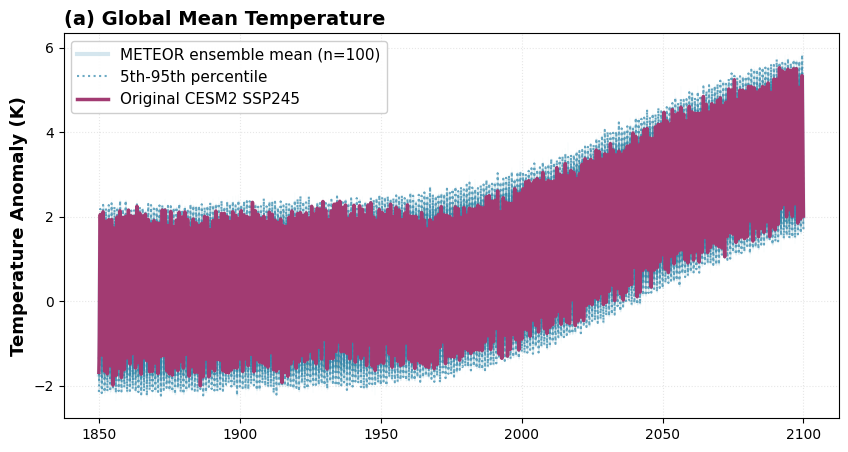

In [55]:
# Create comprehensive 3-panel demonstration figure
fig, axes = plt.subplots(1, 1, figsize=(10, 5), sharex=True)

# Time axis for plotting (zoom to 2020-2035)
time_axis = ssp245_data['month'].values / 12 + 1850
zoom_start, zoom_end = 1850, 2100

# Offset to match monthly_prediction indexing (starts at year 0, corresponds to 1850)
offset = 1200  # Skip first 100 years to align with training period

# Create time mask for the offset data
time_axis_offset = time_axis[:]
time_mask_offset = (time_axis_offset >= zoom_start) & (time_axis_offset <= zoom_end)
time_plot = time_axis_offset[time_mask_offset]

# Create time mask for original data (no offset)
time_mask = (time_axis >= zoom_start) & (time_axis <= zoom_end)

# Plot styling
ensemble_color = '#2E86AB'  # Blue
original_color = '#A23B72'  # Purple/magenta
ensemble_alpha = 0.015
line_width = 0.8

# ============================================================================
# Panel 1: GLOBAL MEAN
# ============================================================================
ax = axes

# Plot ensemble members with transparency
for i in range(n_demo):
    member_data = demo_global.isel(realization=i).values[offset:]
    ax.plot(time_plot, member_data[time_mask_offset], 
            color=ensemble_color, alpha=ensemble_alpha, linewidth=line_width)

# Plot ensemble mean
ensemble_mean_global = demo_global.mean(dim='realization').values[offset:]
ax.plot(time_plot, ensemble_mean_global[:][time_mask_offset], 
        color=ensemble_color, linewidth=3, label=f'METEOR ensemble mean (n={n_demo})', zorder=10,alpha=0.2)

# Plot percentiles (5th and 95th)
perc_05_global = demo_global.quantile(0.01, dim='realization').values[offset:]
perc_95_global = demo_global.quantile(0.99, dim='realization').values[offset:]
ax.plot(time_plot, perc_05_global[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, label='5th-95th percentile', zorder=8)
ax.plot(time_plot, perc_95_global[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, zorder=8)
ax.fill_between(time_plot, perc_05_global[time_mask_offset], perc_95_global[time_mask_offset],
                color=ensemble_color, alpha=0.1, zorder=7)

# Plot original CMIP6 data
ax.plot(time_plot, original_global_mean.values[:,time_mask].T, 
        color=original_color, linewidth=2.5, linestyle='-',
        label=f'Original {model_name} SSP245', zorder=10, marker='', markersize=4, markevery=6)

ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_title('(a) Global Mean Temperature', fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)


In [ ]:
# Create comprehensive 3-panel demonstration figure
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Time axis for plotting (zoom to 2020-2035)
time_axis = ssp245_data['month'].values / 12 + 1850
zoom_start, zoom_end = 2040, 2055

# Offset to match monthly_prediction indexing (starts at year 0, corresponds to 1850)
offset = 1200  # Skip first 100 years to align with training period

# Create time mask for the offset data
time_axis_offset = time_axis[:]
time_mask_offset = (time_axis_offset >= zoom_start) & (time_axis_offset <= zoom_end)
time_plot = time_axis_offset[time_mask_offset]

# Create time mask for original data (no offset)
time_mask = (time_axis >= zoom_start) & (time_axis <= zoom_end)

# Plot styling
ensemble_color = '#2E86AB'  # Blue
original_color = '#A23B72'  # Purple/magenta
ensemble_alpha = 0.015
line_width = 0.8

# ============================================================================
# Panel 1: GLOBAL MEAN
# ============================================================================
ax = axes[0]

# Plot ensemble members with transparency
for i in range(n_demo):
    member_data = demo_global.isel(realization=i).values[offset:]
    ax.plot(time_plot, member_data[time_mask_offset], 
            color=ensemble_color, alpha=ensemble_alpha, linewidth=line_width)

# Plot ensemble mean
ensemble_mean_global = demo_global.mean(dim='realization').values[offset:]
ax.plot(time_plot, ensemble_mean_global[:][time_mask_offset], 
        color=ensemble_color, linewidth=3, label=f'METEOR ensemble mean (n={n_demo})', zorder=10)

# Plot percentiles (5th and 95th)
perc_05_global = demo_global.quantile(0.01, dim='realization').values[offset:]
perc_95_global = demo_global.quantile(0.99, dim='realization').values[offset:]
ax.plot(time_plot, perc_05_global[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, label='5th-95th percentile', zorder=8)
ax.plot(time_plot, perc_95_global[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, zorder=8)
ax.fill_between(time_plot, perc_05_global[time_mask_offset], perc_95_global[time_mask_offset],
                color=ensemble_color, alpha=0.1, zorder=7)

# Plot original CMIP6 data
ax.plot(time_plot, original_global_mean.values[:,time_mask].T, 
        color=original_color, linewidth=2.5, linestyle='--',
        label=f'Original {model_name} SSP245', zorder=9, marker='o', markersize=4, markevery=6)

ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_title('(a) Global Mean Temperature', fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

# ============================================================================
# Panel 2: REGIONAL MEAN (Northern Europe)
# ============================================================================
ax = axes[1]

# Plot ensemble members
for i in range(n_demo):
    member_data = demo_neu.isel(realization=i).values[offset:]
    ax.plot(time_plot, member_data[time_mask_offset], 
            color=ensemble_color, alpha=ensemble_alpha, linewidth=line_width)

# Plot ensemble mean
ensemble_mean_neu = demo_neu.mean(dim='realization').values[offset:]
ax.plot(time_plot, ensemble_mean_neu[time_mask_offset], 
        color=ensemble_color, linewidth=3, label=f'METEOR ensemble mean (n={n_demo})', zorder=10)

# Plot percentiles (5th and 95th)
perc_05_neu = demo_neu.quantile(0.01, dim='realization').values[offset:]
perc_95_neu = demo_neu.quantile(0.99, dim='realization').values[offset:]
ax.plot(time_plot, perc_05_neu[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, label='5th-95th percentile', zorder=8)
ax.plot(time_plot, perc_95_neu[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, zorder=8)
ax.fill_between(time_plot, perc_05_neu[time_mask_offset], perc_95_neu[time_mask_offset],
                color=ensemble_color, alpha=0.1, zorder=7)

# Plot original CMIP6 data
original_neu_anomaly = original_regional_mean - original_pictrl_regional_mean.mean()
ax.plot(time_plot, original_neu_anomaly.values[:,time_mask].T, 
        color=original_color, linewidth=2.5, linestyle='--',
        label=f'Original {model_name} SSP245', zorder=9, marker='o', markersize=4, markevery=6)

ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_title(f'(b) Regional Mean Temperature - Northern Europe (NEU)', 
             fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

# ============================================================================
# Panel 3: POINT-SCALE (Oslo)
# ============================================================================
ax = axes[2]

# Plot ensemble members
for i in range(n_demo):
    member_data = demo_oslo.isel(realization=i).values[offset:]
    ax.plot(time_plot, member_data[time_mask_offset], 
            color=ensemble_color, alpha=ensemble_alpha, linewidth=line_width)

# Plot ensemble mean
ensemble_mean_oslo = demo_oslo.mean(dim='realization').values[offset:]
ax.plot(time_plot, ensemble_mean_oslo[time_mask_offset], 
        color=ensemble_color, linewidth=3, label=f'METEOR ensemble mean (n={n_demo})', zorder=10)

# Plot percentiles (5th and 95th)
perc_05_oslo = demo_oslo.quantile(0.01, dim='realization').values[offset:]
perc_95_oslo = demo_oslo.quantile(0.99, dim='realization').values[offset:]
ax.plot(time_plot, perc_05_oslo[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, label='5th-95th percentile', zorder=8)
ax.plot(time_plot, perc_95_oslo[time_mask_offset], 
        color=ensemble_color, linewidth=1.5, linestyle=':', alpha=0.7, zorder=8)
ax.fill_between(time_plot, perc_05_oslo[time_mask_offset], perc_95_oslo[time_mask_offset],
                color=ensemble_color, alpha=0.1, zorder=7)

# Plot original CMIP6 data
ax.plot(time_plot, original_oslo_anomaly_values[:,time_mask].T, 
        color=original_color, linewidth=2.5, linestyle='--',
        label=f'Original {model_name} SSP245', zorder=9, marker='o', markersize=4, markevery=6)

ax.set_ylabel('Temperature Anomaly (K)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_title(f'(c) Point-Scale Temperature - Oslo ({oslo_lat}°N, {oslo_lon}°E)', 
             fontsize=14, fontweight='bold', loc='left')
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

# Set x-axis limits
for ax in axes:
    ax.set_xlim(zoom_start, zoom_end)

# Overall title
fig.suptitle(f'METEOR Fast Scalar Generation: {n_demo}-Member Ensembles Across Spatial Scales\n{model_name} SSP2-4.5 ({zoom_start}-{zoom_end})', 
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

print(f"\n✅ Created comprehensive 3-panel demonstration figure")
print(f"   Showing global, regional (NEU), and point-scale (Oslo) ensembles")
print(f"   Period: {zoom_start}-{zoom_end}")
print(f"   Ensemble size: {n_demo} members")
print(f"   All scales share identical stochastic variability!")


### Ensemble Adequacy Testing

Test whether the original CMIP6 simulations fall within the METEOR ensemble distribution as expected. If the ensemble is well-calibrated, the original data should be uniformly distributed across the ensemble percentiles.

In [ ]:
def calculate_ensemble_rank(observation, ensemble):
    """
    Calculate the rank of an observation within an ensemble distribution.
    
    Parameters
    ----------
    observation : array-like
        Observed values (time series)
    ensemble : array-like
        Ensemble members (n_members x time)
        
    Returns
    -------
    ranks : array
        Rank percentiles (0-1) for each timestep
    """
    n_members = ensemble.shape[0]
    ranks = np.zeros(len(observation))
    
    for t in range(len(observation)):
        # Count how many ensemble members are below the observation
        count_below = np.sum(ensemble[:, t] < observation[t])
        # Rank as percentile (0 to 1)
        ranks[t] = count_below / n_members
    
    return ranks


# Calculate ranks for each region across the overlapping time period
print("🔍 Calculating ensemble ranks for original CMIP6 data...")
print("="*70)

# Use the time period where we have both METEOR and original data (after offset)
analysis_start_idx = offset  # Start after the offset
analysis_length = min(len(original_global_mean.values[0]), 
                      len(demo_global.values[0]) - offset)

# 1. Global mean ranks (first CMIP6 ensemble member)
global_obs = original_global_mean.values[0, :analysis_length]
global_ens = demo_global.values[:, offset:offset+analysis_length]
global_ranks = calculate_ensemble_rank(global_obs, global_ens)

print(f"✅ Global mean ranks calculated: {len(global_ranks)} timesteps")
print(f"   Mean rank: {np.mean(global_ranks):.3f} (expected: 0.5)")
print(f"   Std rank: {np.std(global_ranks):.3f} (expected: {1/np.sqrt(12):.3f})")

# 2. Regional mean ranks (NEU - first CMIP6 ensemble member)
neu_obs = original_neu_anomaly.values[0, :analysis_length]
neu_ens = demo_neu.values[:, offset:offset+analysis_length]
neu_ranks = calculate_ensemble_rank(neu_obs, neu_ens)

print(f"✅ NEU regional ranks calculated: {len(neu_ranks)} timesteps")
print(f"   Mean rank: {np.mean(neu_ranks):.3f} (expected: 0.5)")
print(f"   Std rank: {np.std(neu_ranks):.3f} (expected: {1/np.sqrt(12):.3f})")

# 3. Point-scale ranks (Oslo - first CMIP6 ensemble member)
# Convert to numpy array if it's an xarray DataArray
if hasattr(original_oslo_anomaly_values, 'values'):
    oslo_obs = original_oslo_anomaly_values.values[0, :analysis_length]
else:
    oslo_obs = original_oslo_anomaly_values[0, :analysis_length]
oslo_ens = demo_oslo.values[:, offset:offset+analysis_length]
oslo_ranks = calculate_ensemble_rank(oslo_obs, oslo_ens)

print(f"✅ Oslo point ranks calculated: {len(oslo_ranks)} timesteps")
print(f"   Mean rank: {np.mean(oslo_ranks):.3f} (expected: 0.5)")
print(f"   Std rank: {np.std(oslo_ranks):.3f} (expected: {1/np.sqrt(12):.3f})")

print("="*70)
print("\n💡 For a well-calibrated ensemble:")
print("   - Ranks should be uniformly distributed between 0 and 1")
print("   - Mean rank ≈ 0.5")
print(f"   - Std rank ≈ {1/np.sqrt(12):.3f} (1/√12 for uniform distribution)")

In [ ]:
# Create histograms showing rank distributions for all three regions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bins = np.linspace(0, 1, 21)  # 20 bins from 0 to 1
expected_count = len(global_ranks) / 20  # Expected count per bin for uniform distribution

regions = [
    ('Global Mean', global_ranks, axes[0]),
    ('NEU Regional Mean', neu_ranks, axes[1]),
    ('Oslo Point', oslo_ranks, axes[2])
]

for region_name, ranks, ax in regions:
    # Plot histogram
    counts, edges, patches = ax.hist(ranks, bins=bins, alpha=0.7, color='#2E86AB', 
                                      edgecolor='black', linewidth=1.2)
    
    # Plot expected uniform distribution line
    ax.axhline(expected_count, color='red', linestyle='--', linewidth=2, 
               label=f'Expected (uniform)', zorder=10)
    
    # Add shaded confidence interval for uniform distribution (±2σ)
    # For binomial: σ = sqrt(n*p*(1-p)) where p=1/20, n=total_timesteps
    p = 1/20
    sigma = np.sqrt(len(ranks) * p * (1-p))
    ax.axhline(expected_count + 2*sigma, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax.axhline(expected_count - 2*sigma, color='red', linestyle=':', linewidth=1, alpha=0.5)
    ax.fill_between([0, 1], expected_count - 2*sigma, expected_count + 2*sigma,
                     color='red', alpha=0.1, zorder=1)
    
    # Labels and formatting
    ax.set_xlabel('Ensemble Rank Percentile', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title(f'{region_name}\nMean: {np.mean(ranks):.3f}, Std: {np.std(ranks):.3f}', 
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=10)
    ax.set_xlim(0, 1)

plt.suptitle('Ensemble Adequacy Test: Original CMIP6 Rank Distribution within METEOR Ensemble', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Histogram Analysis:")
print("   If the ensemble is well-calibrated, histograms should be approximately flat")
print("   (uniform distribution across all percentile bins)")
print(f"   Number of timesteps analyzed: {len(global_ranks)}")
print(f"   Expected count per bin: {expected_count:.1f}")
print(f"   95% confidence interval: [{expected_count - 2*sigma:.1f}, {expected_count + 2*sigma:.1f}]")